In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt


import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein

import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968
cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

In [10]:
path = '../target_selection/photom_redshift_distribution/'


config_survey_dark = {'survey_type': 'Dark',
                 'N_fibres': 30000,
                      'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.45,
                 'tracer_N_zm_file' : [path+f'COSMOS_LBG_udropout_highz.npz',
                                       path+f'COSMOS_LBG_gdropout.npz',
                                       path+f'COSMOS_LBG_rdropout.npz',
                                  ],
                 'tracers' : ['LBGu', 'LBGg' ,
                              'LBGr'
                             ],
                    'color' : ['k', 'm','g','r']}

mag_max_eval_range_dark=[[24.2, 26],[24.2, 26],[24.2, 26]]
max_mag_dark= [25,25,25]
config_dark_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(config_survey_dark, max_mag=max_mag_dark, mag_max_eval_range=mag_max_eval_range_dark)   


 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 


In [11]:
forecast_dark_single= _survey_design_science_metrics.Survey_design_science_metrics(config_dark_update, cosmo, 
                                                                   redshift_eval_range =[[2, 4.5], 
                                                                                         [2.5, 4.9],
                                                                       [4.5, 5.5]
                                                                   ], 
                                                                  mag_max_eval_range=mag_max_eval_range_dark,
                                                                            one_mag_bin_approach = True,
                                                                              multi_mag_bin_approach = False)

Computing forecasts: Survey  Dark  --- tracer:  LBGu
Computing forecasts: Survey  Dark  --- tracer:  LBGg
Computing forecasts: Survey  Dark  --- tracer:  LBGr


In [12]:
%load_ext autoreload
%autoreload 2
forecast_dark_multi = _survey_design_science_metrics.Survey_design_science_metrics(config_dark_update, cosmo, 
                                                                   redshift_eval_range =[
                                                                       [2, 4.5],
                                                                       [2.5, 4.9],
                                                                       [4.5, 5.5]
                                                                   ], 
                                                                   mag_max_eval_range=mag_max_eval_range_dark,
                                                                            one_mag_bin_approach = False,
                                                                              multi_mag_bin_approach = True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Computing forecasts: Survey  Dark  --- tracer:  LBGu
Now, forecasts are done considering 2 samples
Computing forecasts: Survey  Dark  --- tracer:  LBGg
Now, forecasts are done considering 2 samples
Computing forecasts: Survey  Dark  --- tracer:  LBGr
Now, forecasts are done considering 2 samples


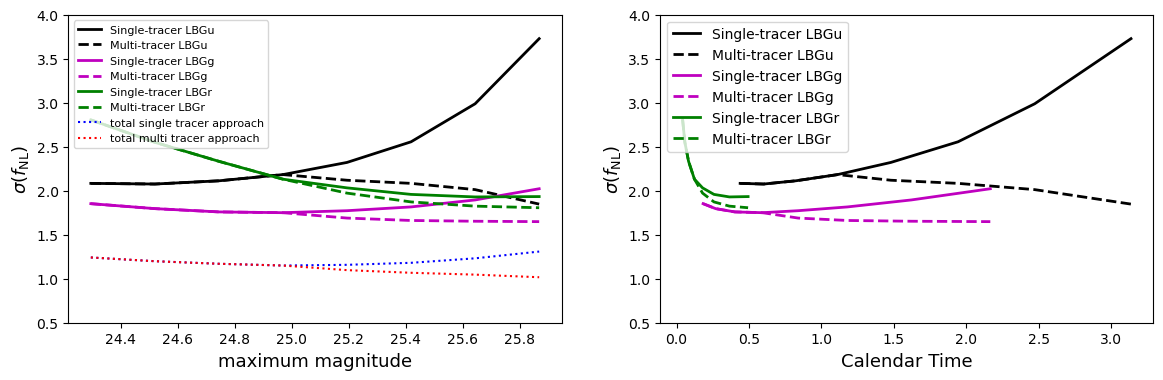

In [14]:
plt.figure(figsize=(14,4))
plt.subplot(121)
for forecast, config in zip([forecast_dark_multi], [config_dark_update]):
    for i,tracer in enumerate(config['tracers']):

        plt.plot(forecast[tracer+'_mag_max_eval'], (1/np.array(forecast_dark_single[tracer+'_sigma_fnl_eff'])**2)**(-0.5), '-'+config['color'][i],
                lw=2, label = f'Single-tracer {tracer}')
        plt.plot(forecast[tracer+'_mag_max_eval'],  (1/np.array(forecast_dark_multi[tracer+'_sigma_fnl_eff'])**2)**(-0.5),'--'+config['color'][i],
                lw=2, label = f'Multi-tracer {tracer}')

        #plt.yscale('log')

        plt.ylabel(r'$\sigma(f_{\rm NL})$', fontsize=13)
        plt.xlabel('maximum magnitude', fontsize=13)
        plt.ylim(0.5, 4)
y1 = np.sum([(1/np.array(forecast_dark_single[tracer+'_sigma_fnl_eff'])**2) for tracer in config['tracers']], axis=0)

plt.plot(forecast[tracer+'_mag_max_eval'], y1**(-0.5), ':b', label='total single tracer approach')

y1 = np.sum([(1/np.array(forecast_dark_multi[tracer+'_sigma_fnl_eff'])**2) for tracer in config['tracers']], axis=0)

plt.plot(forecast[tracer+'_mag_max_eval'], y1**(-0.5), ':r', label='total multi tracer approach')
#plt.yscale('log')
plt.legend(loc='upper left', fontsize=8)
plt.subplot(122)
for forecast, config in zip([forecast_dark_multi], [config_dark_update]):
    for i,tracer in enumerate(config['tracers']):

        plt.plot(config[tracer+'_calendar_time'], (1/np.array(forecast_dark_single[tracer+'_sigma_fnl_eff'])**2)**(-0.5), '-'+config['color'][i],
                lw=2, label = f'Single-tracer {tracer}')
        plt.plot(config[tracer+'_calendar_time'],  (1/np.array(forecast_dark_multi[tracer+'_sigma_fnl_eff'])**2)**(-0.5),'--'+config['color'][i],
                lw=2, label = f'Multi-tracer {tracer}')

        plt.ylabel(r'$\sigma(f_{\rm NL})$', fontsize=13)
        plt.xlabel('Calendar Time', fontsize=13)
        plt.ylim(0.5, 4)
plt.legend(loc='upper left')